# Basic Compute

**Resources, pipelines, shaders, descriptor sets, command buffer managers**

Vulky provides a simplified wrapper around Vulkan API objects. However, some Vulkan concepts are abstracted as composite objects within Vulky. A key example is the `Pipeline` object.

In Vulky, a `Pipeline` encapsulates all necessary components to execute shader-based computations, including:
- Shader modules (`VkShaderModule`)
- Descriptor set layouts and bindings
- Framebuffers and render passes
- Resource descriptors

In this notebook, we demonstrate how to use Vulky to generate the classic Mandelbrot set. This serves as a practical introduction to the `Pipeline`, `CommandManager`, and core resource management in Vulky.


In [1]:
try: # install all dependencies in colab 
    import google.colab
    !sudo apt-get update -y
    !sudo apt-get install -y libnvidia-gl-555 vulkan-tools glslang-tools vulkan-validationlayers-dev
    !pip install pyav==13.1.0
    !pip install git+https://github.com/rendervous/vulky_project.git
except:
    print("Executing locally")

Executing locally


In [2]:
import vulky as vk
vk.create_device(debug=True)  # good to devise errors not handled by vulky and fallback on vulkan.

[INFO] Debug instance created...
[PRINT] Inserted device layer "VK_LAYER_KHRONOS_validation" (C:\VulkanSDK\1.3.275.0\Bin\.\VkLayer_khronos_validation.dll)
[PRINT] Inserted device layer "VK_LAYER_OBS_HOOK" (C:\ProgramData\obs-studio-hook\.\graphics-hook64.dll)
[PRINT] Inserted device layer "VK_LAYER_NV_optimus" (C:\WINDOWS\System32\DriverStore\FileRepository\nv_dispi.inf_amd64_cc569e59ca39c5fe\.\nvoglv64.dll)
[PRINT] vkCreateDevice layer callstack setup to:
[PRINT]    <Application>
[PRINT]      ||
[PRINT]    <Loader>
[PRINT]      ||
[PRINT]    VK_LAYER_NV_optimus
[PRINT]            Type: Implicit
[PRINT]                Disable Env Var:  DISABLE_LAYER_NV_OPTIMUS_1
[PRINT]            Manifest: C:\WINDOWS\System32\DriverStore\FileRepository\nv_dispi.inf_amd64_cc569e59ca39c5fe\nv-vk64.json
[PRINT]            Library:  C:\WINDOWS\System32\DriverStore\FileRepository\nv_dispi.inf_amd64_cc569e59ca39c5fe\.\nvoglv64.dll
[PRINT]      ||
[PRINT]    VK_LAYER_OBS_HOOK
[PRINT]            Type: Implici

Vulky represents resources and their views using the same object. Internally, memory shared by different aliases is properly managed. However, all operations involving bindings, copies, and similar tasks treat resources as having an intrinsic *view* or *slice*.

Resources in Vulky follow a hierarchical structure:

- `Buffer`: A general-purpose raw buffer. Buffers can be sliced using an offset and size.
- `StructuredBuffer`: A buffer that can be accessed as an array of structures.
- `ObjectBuffer`: A persistently mapped buffer accessible using simple dot notation.
- `Image`: A 1D, 2D, or 3D image used for storing texels, sampling, or attaching as a render target or depth buffer. Images consist of multiple subresources (e.g., layers and mip levels).
- `Sampler`: A descriptor that defines how texels are sampled from an image.

In the following example, we create an image to serve as a render target and an `ObjectBuffer` (used as a uniform buffer) to specify properties for the fractal generator. 

A common pattern in Vulky is to declare named fields using keyword arguments. Note how the layout declaration is defined using the syntax:  
```field_name=field_type```.


In [3]:
SCREEN_WIDTH = 512
SCREEN_HEIGHT = 512

render_target = vk.image_2D(
    image_format=vk.Format.VEC4,
    width=SCREEN_WIDTH,
    height=SCREEN_HEIGHT,
    mips=1,  # Important to make the image single resource
    usage=vk.ImageUsage.STORAGE,
    memory=vk.MemoryLocation.GPU
)

parameters_buffer = vk.object_buffer(
    layout=vk.Layout.from_structure(vk.LayoutAlignment.STD430,
        C=vk.vec2,
        W=float,
    ),
    memory=vk.MemoryLocation.GPU
)

Now, let's define the compute shader that will generate the fractal.

In [4]:
compute_shader_code = """
#version 460
#extension GL_EXT_scalar_block_layout: require

layout (local_size_x = 32, local_size_y = 32, local_size_z = 1) in;

layout(binding = 0, rgba32f) uniform image2D render_target;
layout(binding = 1, std430) uniform Parameters { vec2 C;  float W; };

vec4 get_color(float m) {
    m = min(m, 100.0);
    float s = 2*(1.0 / (1 + exp(-m)) - 0.5);
    // return vec4(1 - s, 1.0-s*s, mod(s+0.5, 1.0), 1.0);
    return vec4(1 - s*s, 1 - s, mod(s*s + 0.5, 1.0), 1.0);
}

void main() {
    ivec3 thread_id = ivec3(gl_GlobalInvocationID);
    ivec2 dim = imageSize(render_target);
    vec2 c = C + W * vec2((thread_id.x + 0.5) / dim.x, (thread_id.y + 0.5) / dim.y) - W/2.0;
    vec2 Z = vec2(0., 0.);
    for (int i=0; i<256; i++)
        Z = vec2(Z.x*Z.x - Z.y*Z.y, 2*Z.x*Z.y) + c;
    float m = sqrt(dot(Z, Z));

    imageStore(render_target, thread_id.xy, get_color(m));    
}
    """

In the example code, the shader expects a pipeline that binds a texture and a uniform buffer using the `std430` layout. 

In Vulkan, achieving this setup requires combining several low-level objects (e.g., shader modules, descriptor set layouts, and pipeline layouts). Vulky simplifies this process through the `Pipeline` abstraction.

Pipelines in Vulky follow a hierarchy based on the GPU execution engine they are intended for:

- `Pipeline`: Base object that sets up shader modules, resource bindings, and creates compatible descriptor collections.
- `ComputePipeline`: A specialized `Pipeline` compatible with compute command buffer managers.
- `GraphicsPipeline`: A `Pipeline` extension for graphics work. It allows the declaration of attachments, vertex bindings, and vertex input formats.
- `RaytracingPipeline`: A `Pipeline` extension for ray tracing workloads. It supports the creation of shader groups and integration with ray tracing command managers.

This hierarchical design allows you to manage GPU workloads with minimal boilerplate, while maintaining flexibility across different execution engines.


In [5]:
pipeline = vk.pipeline_compute()
pipeline.layout(set=0, binding=0, render_target=vk.DescriptorType.STORAGE_IMAGE)
pipeline.layout(set=0, binding=1, parameters_buffer=vk.DescriptorType.UNIFORM_BUFFER)
pipeline.load_shader_from_source(compute_shader_code)
pipeline.close()

The `layout` method is used to specify each resource that is part of the pipeline’s bindings. Each resource is declared using a single keyword argument that names the binding. This name is later used to refer to the actual resource when descriptor sets are created.

After a pipeline is created, it remains *open* for setup — allowing you to define layouts and other configurations. Once setup is complete, the pipeline must be *closed*. After closing, the pipeline becomes ready for use: you can create descriptor sets from it and bind it within a command buffer.


In [6]:
global_bindings = pipeline.create_descriptor_set_collection(set=0, count=1)

Descriptor sets in Vulky are created in **collections** (which can consist of just one set). This design is useful for scenarios such as:

- Updating descriptor sets while others are still in use (e.g., triple-buffering)
- Creating multiple instances of the same descriptor layout to represent different objects (e.g., local transforms or per-object properties)

In this example, we create a **single global binding set**. Resources are bound using the same reference names declared earlier in the `layout` method.

The `set` parameter specifies which descriptor set index is being created, while the `count` parameter defines how many compatible copies of that set to allocate.


In [7]:
global_bindings[0].update(
    render_target=render_target,
    parameters_buffer=parameters_buffer
)

The descriptor update occurs explicitly at this point, and is equivalent to writing descriptor sets in raw Vulkan.

**Important:** Vulky does not internally guard against updating descriptor sets that are currently in use by the GPU. Such misuse will trigger Vulkan validation errors or undefined behavior. It is the user's responsibility to ensure that descriptor sets are not modified while being accessed by the GPU.


The parameters stored in `parameters_buffer` should be updated **before** command buffer submission.

When using an `ObjectBuffer` within a context, you gain access to an accessor that allows natural field access using dot notation—making updates to structured data more intuitive and readable.


In [8]:
with parameters_buffer as b:
    b.C = vk.vec2(-.748, .1)
    b.W = 0.01

Now that all components are in place, we can execute the fractal generation on the GPU.

First, create a manager object to issue compute commands using `compute_manager`. When used within a context, this manager records commands into an internal command buffer and automatically submits it upon exiting the context.

This simplifies execution and ensures proper synchronization.


In [9]:
with vk.compute_manager() as man:
    man.set_pipeline(pipeline)
    man.bind(global_bindings[0])
    man.dispatch_threads_2D(render_target.width, render_target.height)

With a command buffer manager (e.g., `man`), the first step is to **set the pipeline**. Next, we **bind the descriptor set** (in this case, `global_bindings[0]`), and finally, we **dispatch threads** on the GPU to compute the fractal.

The method `dispatch_threads_X` calculates and dispatches the appropriate number of thread groups to cover the requested number of threads. For 2D grids, the default group size is `(32, 32, 1)`, but a custom group size can also be specified if needed.

Alternatively, you can use `dispatch_groups` to manually specify the number of workgroups to dispatch.


At this point, the GPU submission and execution have completed. This is because using a command manager within a context ensures that the recorded commands are submitted and the GPU finishes execution before exiting the context.

Now, we can copy the rendered image to a staging tensor for visualization. Vulky is well integrated with PyTorch, allowing efficient data transfer from Vulkan resources to PyTorch tensors.


In [10]:
staging = vk.tensor(render_target.height, render_target.width, 4)
render_target.save(staging)

Note that the tensor used for copying may have any shape, but its final size **must be compatible** with the image being saved. The `save` operation does **not** perform any blitting or resizing—though blit operations are supported separately if needed.

Now, we’ll display the image using Matplotlib.


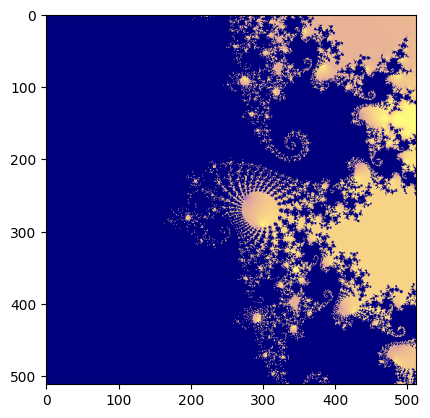

In [11]:
import matplotlib.pyplot as plt
plt.imshow(staging.cpu())
plt.show()

Let’s create a simple animation using the fractal generator. 

Note that we **reuse a recorded command buffer** for all frames. This improves performance by avoiding redundant command recording and allows efficient GPU execution across animation frames.

In [12]:
video_data = vk.tensor(100, SCREEN_HEIGHT, SCREEN_WIDTH, 3)  # 100 frames

man = vk.compute_manager()
man.set_pipeline(pipeline)
man.bind(global_bindings[0])
man.dispatch_threads_2D(render_target.width, render_target.height)
man.freeze()  # can be re-submitted several times

for i in range(len(video_data)):
    # update buffer
    with parameters_buffer as b:
        b.C = vk.vec2(-.74942, .07195)
        b.W = 2.0 * (0.9 ** (100 * i / len(video_data)))
    # re-submit commands to gpu
    vk.submit(man)  # by default will wait until finishes
    render_target.save(staging)
    video_data[i] = staging[...,:3]  # copy current frame to video (only RGB)
vk.save_video(video_data, 'teaser2.webp', 10, quality=100)

To display the animation, you can use a dedicated **tool method** provided by *Vulky* that handles video playback seamlessly.

In [13]:
vk.notebook_show('teaser2.webp')